<a href="https://colab.research.google.com/github/aadevezhilarasan-brown/Team6_logistic_regression_1_3/blob/main/Team6_logistic_regression_1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:#4E3629;color:#fff;padding:20px 24px;border-radius:8px;font-family:Lato,Arial,Helvetica,sans-serif;"><div style="color:#E9C9C9;font-size:13px;letter-spacing:1.5px;font-weight:bold;">SUMMER@BROWN 2026 &middot; INTRODUCTION TO DATA SCIENCE</div><div style="font-size:27px;font-weight:bold;margin-top:6px;">Assignment 1.3 &mdash; Who Should the Bank Call?</div><div style="font-size:15px;margin-top:6px;color:#f1eae5;">Logistic Regression &middot; Your First Team Project &middot; Python</div><div style="height:4px;background:#990000;margin-top:14px;border-radius:2px;"></div></div>

## The mission
Your team is the new **data science unit at a Portuguese bank**. The bank sells **term deposits** through **phone-call campaigns** — but the call centre **can’t phone everyone**. Using data from past campaigns (45,211 contacts), you’ll build a **logistic regression** model that estimates each client’s *probability* of subscribing, then rank clients so the bank calls the **most promising first**.

The target `y` is binary (subscribed = yes/no), which is exactly what logistic regression is for: it returns a probability between 0 and 1.

<div style="border-left:6px solid #990000;background:#FAF4EC;padding:14px 18px;border-radius:4px;font-family:Lato,Arial,sans-serif;"><b style="color:#990000;">How this builds on Assignments 1.1 and 1.2</b><br>You already have every tool — this connects them:<ul style="margin:8px 0 0 0;"><li><b>1.2 → missing data:</b> last time you <i>dropped</i> rows; here you’ll <i>impute</i> — and first uncover values hidden as "unknown".</li><li><b>1.2 → hypothesis testing:</b> a t-test on numbers becomes a <b>chi-square test</b> on categories.</li><li><b>1.2 → regression:</b> linear regression predicted a <i>number</i>; logistic regression predicts a <i>probability</i>.</li><li><b>1.2 → train/test &amp; “don’t peek”:</b> the split returns, plus scaling fit on the training set only.</li><li><b>1.1 → storytelling:</b> you’ll finish with a one-paragraph recommendation for the bank.</li></ul></div>

## Working as a team: Colab + GitHub
This is your **first team project**, and collaboration is graded. Use **Google Colab** to write and run code together in real time, and **GitHub** for version control and submission. Edit together in Colab during live sessions; at each milestone use **File → Save a copy in GitHub** to commit, *early and often*.

**Why notebooks fight git:** an `.ipynb` is JSON, so if two people edit the *same cell* and both push you get an ugly merge conflict. Avoid it: one **driver** types during live sessions, each member **owns specific sections**, and **pull before / commit after** you work.

**You’re an international cohort** — coordinating across **time zones** is real. Agree on meeting times *in everyone’s local time* and record them in the charter.

### ✉ Team Charter (fill in before coding)

| Field | Your team’s entry |
|---|---|
| Team number |06|
| Members (name — **time zone**) |Aadev Ezhilarasan - CST, Priyanka Keshavan - PST, William Ding - PST, William Ocran - EST |
| Section owners |Aadev - Analyst / PM, Priyanka - Data Wrangler, William D - Modeler, William O - Evaluator|
| Synchronous meeting times (**each member’s local time**) |7/7: Priyanka, William & William @5:30 p.m., Aadev @ 7:30
 |
| Async channel + expected response time |Instagram, 1-2hr Response Time|
| How you’ll avoid notebook merge conflicts |Divvying work ahead of time and notifying everyone of every major action taken inside the document|

**Suggested roles** (everyone writes code *and* answers red questions):
**Data Wrangler** (Sec 1–3) ·
**Analyst** (Sec 4 + 6) ·
**Modeler** (Sec 5 & 7) ·
**Evaluator** (Sec 8–9) ·
**PM / Storyteller** (framing, Sec 10, ReadMe + charter).

## The dataset & what every column means
The file is **`bank-full.csv`** (45,211 rows). **It is semicolon-separated** — read it with `sep=';'`. Here is what each variable means:

| Variable | Meaning | Type |
|---|---|---|
| `age` | Client’s age, in years | numeric |
| `job` | Type of job (admin., technician, management, …) | categorical |
| `marital` | Marital status (married / single / divorced) | categorical |
| `education` | Education level (primary / secondary / tertiary) | categorical |
| `default` | Has credit in default? | yes / no |
| `balance` | Average yearly balance, in euros (can be negative) | numeric |
| `housing` | Has a housing loan? | yes / no |
| `loan` | Has a personal loan? | yes / no |
| `contact` | How the client was contacted (cellular / telephone) | categorical |
| `day` | Day of the month of the last contact | numeric |
| `month` | Month of the last contact (jan … dec) | categorical |
| `duration` | Last call duration, in seconds | numeric — **⚠️ drop it (see below)** |
| `campaign` | # contacts during this campaign for this client | numeric |
| `pdays` | Days since the client was last contacted in a previous campaign | numeric (**−1 = never contacted**) |
| `previous` | # contacts before this campaign | numeric |
| `poutcome` | Outcome of the *previous* campaign (failure / other / success) | categorical |
| **`y`** | **TARGET — did the client subscribe to the term deposit?** | **yes / no** |

<div style="border-left:6px solid #4E3629;background:#F2EEE9;padding:12px 16px;border-radius:4px;font-family:Lato,Arial,sans-serif;"><b style="color:#4E3629;">Three things to know before you start</b><ul style="margin:8px 0 0 0;"><li><b>"unknown" means missing.</b> In <code>job</code>, <code>education</code>, <code>contact</code>, and <code>poutcome</code>, the value <code>"unknown"</code> is really a missing value in disguise — so you must surface it before you can impute (Section 3).</li><li><b>Drop <code>duration</code>.</b> It’s only known <i>after</i> a call ends, so it can’t help you decide whom to call — and it basically gives away the answer. Keeping it is <b>data leakage</b> (Section 5).</li><li><b><code>pdays = −1</code></b> is a code for “never previously contacted,” not a real day count.</li></ul></div>

<div style="font-size:12px;color:#8A7F75;font-family:Lato,Arial,sans-serif;">Dataset: S. Moro, R. Laureano and P. Cortez (2011). <i>Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology.</i> In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference — ESM’2011, pp. 117–121, Guimarães, Portugal, October 2011. EUROSIS. Available: http://hdl.handle.net/1822/14838</div>

## Grading scheme (150 points)

| # | Section | Points |
|---|---|---|
| 1 | Importing libraries & loading data | 10 |
| 2 | Data exploration & descriptive stats | 10 |
| 3 | Surfacing & imputing missing values | 15 |
| 4 | Hypothesis test (chi-square) | 15 |
| 5 | Pre-processing (drop leakage, encode) | 15 |
| 6 | Data visualization | 10 |
| 7 | Model building (split, scale, fit) | 20 |
| 8 | Evaluation (confusion, baseline, ROC/AUC) | 15 |
| 9 | Campaign simulation (who to call) | 10 |
| 10 | Final recommendation (storytelling) | 5 |
| 11 | Red questions | 15 |
| 12 | Teamwork & process | 10 |
| | **Total** | **150** |

**Bonus (up to +10):** +5 for beating the majority-class baseline on **AUC** (not raw accuracy); +5 for an optional Random Forest leaderboard entry.

**How to read this notebook:** markdown intros open each section; <span style="color:#990000"><b>red questions</b></span> are answered in your own words in the cell provided; **`# <Your code here>`** marks where you write code. “Expected output” notes describe the *shape* of the result — match the idea, not every digit.

## 1) Importing libraries

The starter cell imports far more than this notebook needs. **Delete every import you don’t actually use.**

In [ ]:
# KEEP ONLY THE LIBRARIES THIS NOTEBOOK ACTUALLY USES; DELETE THE REST.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
import itertools
import subprocess
from time import time
from collections import Counter
from scipy import stats
from scipy.stats import chi2_contingency
import scipy.optimize as opt
from textblob import TextBlob
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

warnings.filterwarnings("ignore")

### <span style="color:#990000">Q1. Why keep only the libraries the notebook actually uses? Give at least two reasons.</span>

> *Write your team's answer in this cell (double-click to edit). No word limit.*

"It's better to keep only the libraries the notebook actually uses because when running all the cells, having large libraries that are not utilized creates unnecessary runtime. Additionally, every library loaded takes up space in memory which could cause the notebook to crash if there were too many."

## 2) Importing the data & descriptive statistics

Load `bank-full.csv` — **remember it is semicolon-separated** — then confirm it imported correctly.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# READ THE DATA  (the file is SEMICOLON-separated!)
# <Your code here>
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/bank-full.csv", sep=";") #save bank-full.csv to your google drive in Colab Notebooks folder

data.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/bank-full.csv'

In [ ]:
TARGET = "y"      # the column that records whether the client subscribed (yes/no)
print("Target column:", TARGET)
print(data.columns.tolist())

Target column: y
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [ ]:
# 1. DIMENSIONS
# <Your code here>
print(data.shape)

(45211, 17)


In [ ]:
# 2. FIRST 15 ROWS
# <Your code here>
data.head(15)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [ ]:
# 3. LAST 5 ROWS
# <Your code here>
data.tail(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [ ]:
# 4. DESCRIPTIVE STATISTICS
# <Your code here>
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## 3) Surfacing & imputing missing values

In **1.2** you *dropped* rows with missing data; here every row is a client the bank paid to contact, so we **impute** instead. But first a twist: this dataset hides its missing values as the text **`"unknown"`**. Surface them, *then* impute — mean for numeric, mode for categorical.

**Step 1 (given):** turn the hidden `"unknown"` values into real missing values so pandas can see them.

In [ ]:
# Surface the hidden missing values
data = data.replace("unknown", np.nan)

In [ ]:
# CHECK FOR MISSING VALUES (per column)
# <Your code here>
data.isnull().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day,0


In [ ]:
# IMPUTE NUMERIC COLUMNS WITH THE MEAN
# <Your code here>
num_cols = data.select_dtypes(include= ['number']).columns
data [num_cols] = data[num_cols].fillna(data[num_cols].mean())

In [ ]:
# IMPUTE CATEGORICAL COLUMNS WITH THE MODE (not the target)
# <Your code here>
cat_cols = data.select_dtypes(include=['object']).columns
cat_cols = cat_cols.drop('y')
data [cat_cols] = data[cat_cols].fillna(data[cat_cols].mode().iloc[0])

In [ ]:
# Confirm no missing values remain
print("missing values left:", int(data.isnull().sum().sum()))
data.head(10)

missing values left: 0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,cellular,5,may,261,1,-1,0,failure,no
1,44,technician,single,secondary,no,29,yes,no,cellular,5,may,151,1,-1,0,failure,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,cellular,5,may,76,1,-1,0,failure,no
3,47,blue-collar,married,secondary,no,1506,yes,no,cellular,5,may,92,1,-1,0,failure,no
4,33,blue-collar,single,secondary,no,1,no,no,cellular,5,may,198,1,-1,0,failure,no
5,35,management,married,tertiary,no,231,yes,no,cellular,5,may,139,1,-1,0,failure,no
6,28,management,single,tertiary,no,447,yes,yes,cellular,5,may,217,1,-1,0,failure,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,cellular,5,may,380,1,-1,0,failure,no
8,58,retired,married,primary,no,121,yes,no,cellular,5,may,50,1,-1,0,failure,no
9,43,technician,single,secondary,no,593,yes,no,cellular,5,may,55,1,-1,0,failure,no


### <span style="color:#990000">Q2. In 1.2 you <i>deleted</i> rows with missing data; here you <i>fill them in</i> — and the data even hid the gaps as "unknown". Why is imputing often better when every row is a client the bank doesn’t want to lose? When might imputing be a bad idea here?</span>

> *Write your team's answer in this cell (double-click to edit). No word limit.*

"Imputing is better when every row is valuable and especially in this scenario because deleting a row means deleting all a customer's data. By deleting every row with a missing value, countless data could get lost which is bad since the model is supposed to predict for ALL the bank's customers. Despite this, imputing can be a bad idea here because it could assume something about a client that could have further repurcussions if incorrect. For example, if "job" was imputed incorrectly with the mode, some bias could be introduced into the model."

### <span style="color:#990000">Q3. Why impute the <b>mean</b> for numeric columns but the <b>mode</b> for categorical columns?</span>

> *Write your team's answer in this cell (double-click to edit). No word limit.*

"The mean is imputed for numeric columns because it represents the center of the overall distribution when considering all the data. Categorical columns use the mode because since the values aren't numeric, you can't find the center or average of the data. Using the most common category is the best guess since it's true for majority of the data."

## 4) Hypothesis test (chi-square) — callback to 1.2

Test a hunch the way you did in 1.2, but for **categorical** data, using a **chi-square test of independence**: *is the outcome of the previous campaign (`poutcome`) associated with subscribing now?* Run it **before** encoding.

In [ ]:
import pandas as pd # Ensure pandas is imported

feature = "poutcome"     # try others too, e.g. "job" or "housing"

# 1. Contingency table: feature vs TARGET
table = pd.crosstab(data["poutcome"], data["y"])      # pd.crosstab(data[feature], data[TARGET])

# 2. Chi-square test of independence
chi2, p, dof, expected = chi2_contingency(table)      # chi2, p, dof, expected = chi2_contingency(table)

# 3. Print the chi-square statistic and the p-value
print(table)
print(f"chi-square = {chi2:.1f} p-value = {p:.3f} dof = {dof}")

NameError: name 'data' is not defined

### <span style="color:#990000">Q4. State H₀ and H₁ for this test. Based on the p-value, at the 0.05 level is `poutcome` associated with subscribing? What does that mean for the bank?</span>

> The Null Hypothesis is that there is no association between the outcome of the previous marketing campaign and whether a client decides to subscribe to a term deposit. The Alternative Hypothesis is that there is a statistically significant association between the outcome of the previous marketing campaign and whether a client decides to subscribe to a term conclusion. Because the p-value is well below the 0.05 significance level, we reject the null hypothesis. This means that there is a highly significant relationship between poutcome and subscribing. This means that the bank should prioritize going after clients who have a positive stance on the past campaigns so that they can minimize wasted calls and conversations.

## 5) Pre-processing: drop leakage, then encode

**Step 1 (given) — drop `duration`.** Call duration is only known *after* the call, so it can’t inform *whom to call*, and it all but reveals the outcome. Keeping it is **data leakage**.

In [ ]:
data = data.drop(columns=["duration"])

### <span style="color:#990000">Q5. Why must we drop `duration` for a model that decides <i>whom to call</i>? What kind of mistake is keeping it, and what would happen to our scores if we left it in?</span>

> The 'duration' of a phone call is not known until after the phone call occurs. By keeping duration in the model, the model will use the value of 'duration' to predict yes or no for subscribing. This may benefit the testing set of data, as it includes duration, but for future clients will only hinder the model as duration is an unknown variable until the call actually happens, which is data leakage.

**Step 2 — encode.** Label-encode the **target** to a single 0/1 column; one-hot encode the categorical **features** only (don’t leak the target).

In [ ]:
# --- TARGET: make it a single 0/1 column (values are lowercase "yes"/"no") ---
y_series = data[TARGET].map({"yes": 1, "no": 0})
y_series.head(10)

# --- FEATURES: one-hot encode categorical FEATURES only ---
features = data.drop(columns=[TARGET])
ohe = OneHotEncoder(sparse_output=False)   # current scikit-learn uses sparse_output (not sparse=)
data_transformed = pd.DataFrame(index=features.index)

for column in features.columns:
    if features[column].dtype == "object":
        # one-hot encode this categorical feature; name columns like column_value
        ohe_columns_df = pd.DataFrame(ohe.fit_transform(features[[column]]),
                                      columns = ohe.get_feature_names_out([column]),
                                      index = features.index)
        data_transformed = pd.concat([data_transformed, ohe_columns_df], axis = 1)
        pass
    else:
        # numeric column: copy across unchanged
        data_transformed[column] = features[column]
        pass

data_transformed[TARGET] = y_series.values
data = data_transformed
data.head(10)



,age,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,month_nov,month_oct,month_sep,campaign,pdays,previous,poutcome_failure,poutcome_other,poutcome_success,y
0,58,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
1,44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
2,33,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
3,47,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
4,33,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
5,35,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
6,28,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
7,42,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
8,58,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
9,43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0


### <span style="color:#990000">Q6. Why one-hot encode the features but label-encode the target? What could go wrong if you one-hot encoded the target instead?</span>

> The features are one-hot encoded to prevent the model from seeing different states of the features (eg. admin vs. blue collar) as being hierarchical. By one-hot encoding, each different category is set as a binary value.

> The target must be label-encoded as the target should be one column that is binary. The original target column was already binary (y/n), so it can be label included (mapping y to 1 and n to 0). However, if the target were to be one-hot encoded, the target would be split into 2 columns (y_yes and y_no), which logistic regression could not be applied to predict both columns. It also introduces confusion as 'yes' is represented as a 1 in one column, but 'no' is also represented as a 1 in the other.

## 6) Data visualization

Plot **histograms** of every column, then a correlation **heatmap**. *Expected output:* a grid of histograms and a coloured heatmap.

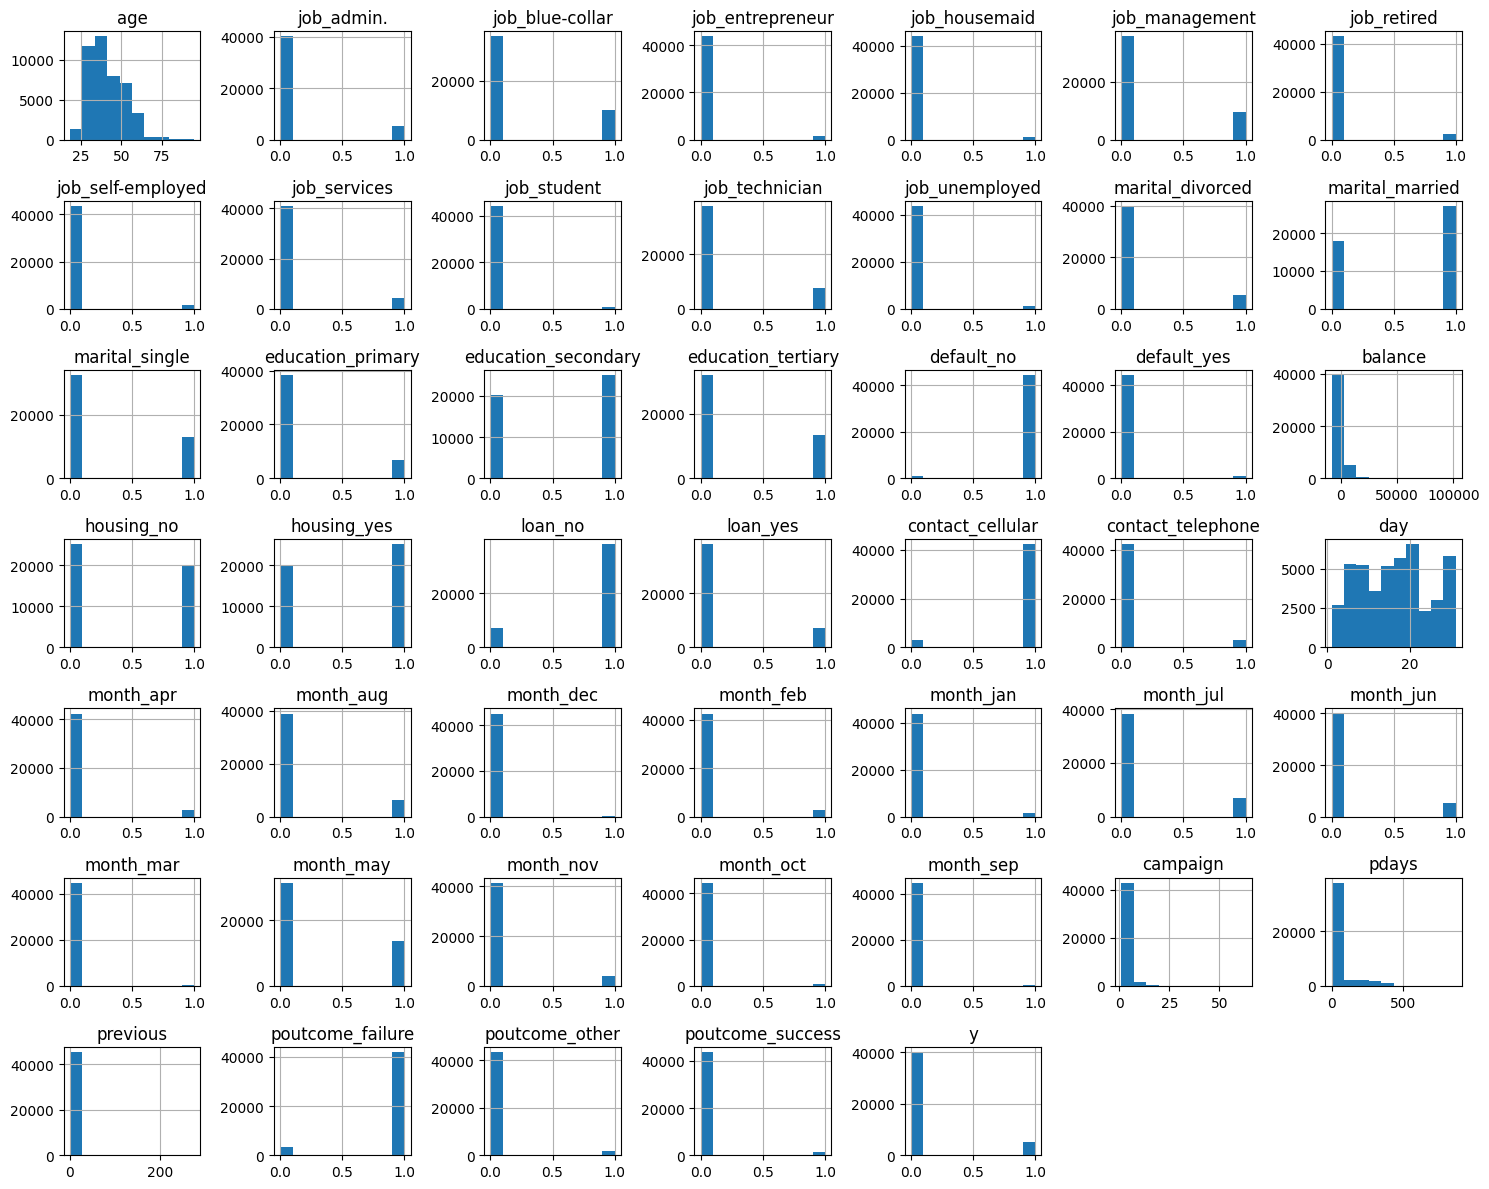

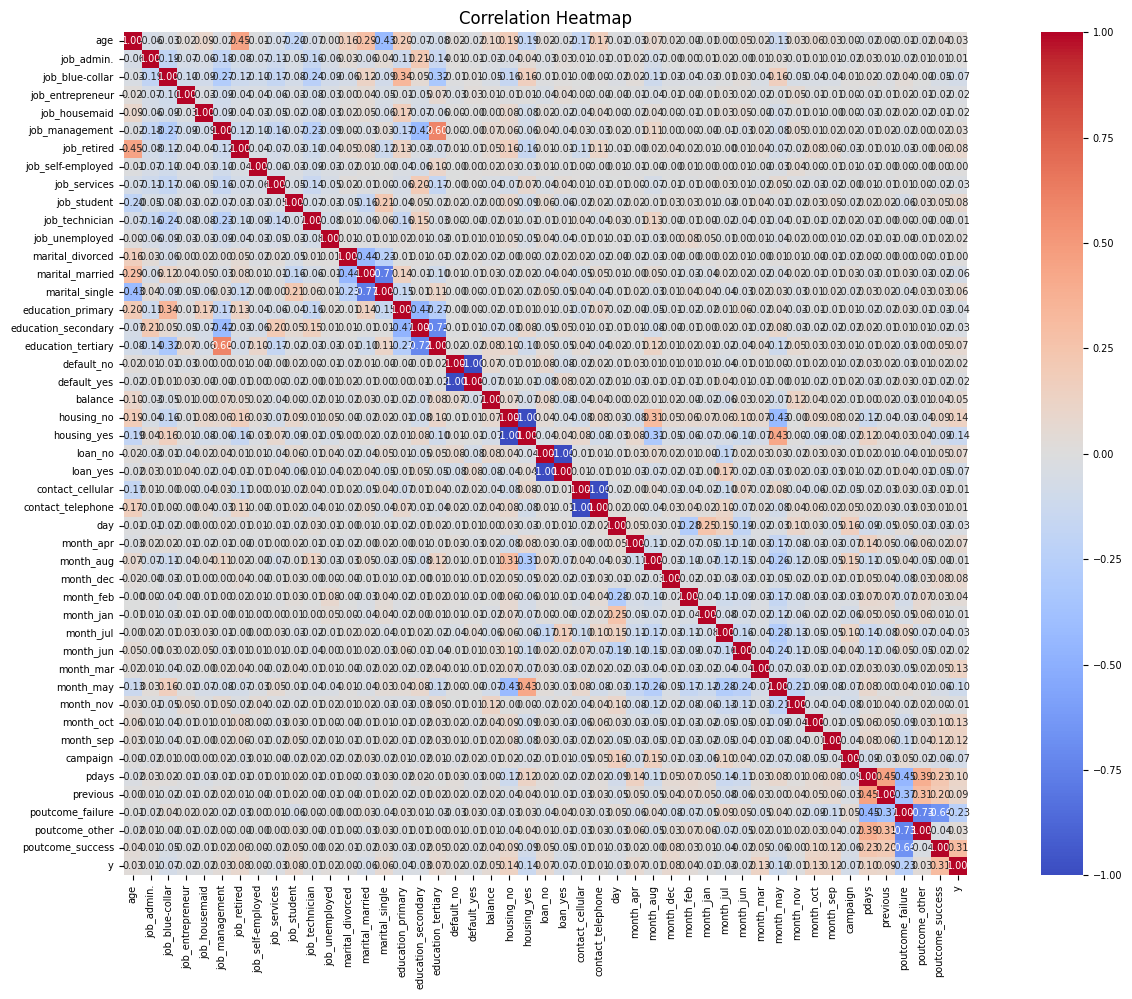

In [ ]:
# HISTOGRAMS
# <Your code here>
data.hist(figsize=(15, 12))
plt.tight_layout()
plt.show()

# CORRELATION MATRIX + HEATMAP
plt.rcParams["font.size"] = 7
plt.figure(figsize =(15, 10))
matrix = data.corr()
sns.heatmap(matrix, annot = True, fmt = ".2f", cmap = "coolwarm", square = True)
plt.title("Correlation Heatmap", fontsize = 12)
plt.tight_layout()
plt.show();
# <Your code here>

### <span style="color:#990000">Q7. Describe the histograms — which features are skewed?</span>

> Some variables that are skewed to the right are age, balance, and campaign. For age, the customer base drops as you get closer to retirement age. For balance, the majority of clients keep a normal amount of wealth with there being some people who have more wealth. For campaign, most clients are contacted every so often while some are contacted excessively.

### <span style="color:#990000">Q8. What does the correlation heatmap reveal? Is any single feature strongly correlated with the target?</span>

> The correlation heatmat reveals that no feature has a strong linear relationship with the target variable as they all vary around 0. However, poutcome_success has the strongest positive correlation with the target as seen by the brighter color.

## 7) Model building

Recall from **1.2**: linear regression drew a line for a *number*; logistic regression bends it into an **S-curve** so the output is a probability in [0, 1].

In [ ]:
# 1. FEATURES (X) AND TARGET (y)
X = data.drop(columns = TARGET)
y = data[TARGET]

# 2. TRAIN / TEST SPLIT (test_size=0.2, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. SCALE — fit on TRAIN ONLY, then transform both
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 4. FIT LOGISTIC REGRESSION
logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train_scaled, y_train)
print(f"trained on {X_train_scaled.shape[0]} clients, {X_train_scaled.shape[1]} features")

trained on 36168 clients, 46 features


### <span style="color:#990000">Q9. Why split into train and test sets? And why fit the scaler on the <b>training</b> set only?</span>

> Train and test sets are used so that the model can be evaluated on new data after training. By doing this, it can be seen whether the model is overfit (does not work well on new data). The scaler is only fit on the training set to prevent data leakage of the test set parameters to the model---this could skew the predictions of the model on the test set to a higher average accuracy.


## 8) Model evaluation

**Accuracy can lie** when one class is rare. Print accuracy and the confusion matrix, compute the **lazy baseline**, then plot the **ROC curve / AUC**.

accuracy: 0.8939511224151278

confusion matrix: 
[[7893   92]
 [ 867  191]]


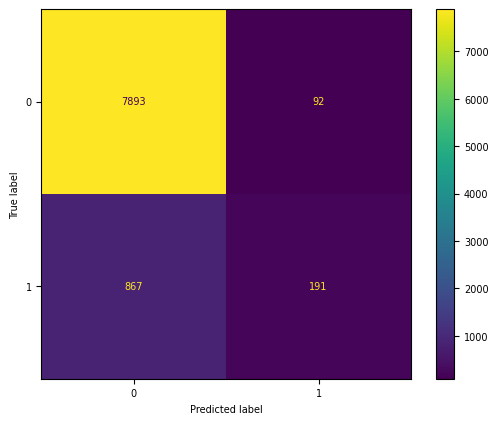

In [ ]:
# PREDICT + ACCURACY
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score)
import matplotlib.pyplot as plt
import numpy as np


y_pred = logreg.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("accuracy:", accuracy)

# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
print("\nconfusion matrix: ")
print(cm)

ConfusionMatrixDisplay(cm).plot()
plt.show()

In [ ]:
# THE LAZY BASELINE: predict the majority class for everyone
lazy_baseline = max(np.mean(y_test == 0), np.mean(y_test == 1))
print("Lazy Baseline Accuracy:", lazy_baseline)

Lazy Baseline Accuracy: 0.8830034280659074


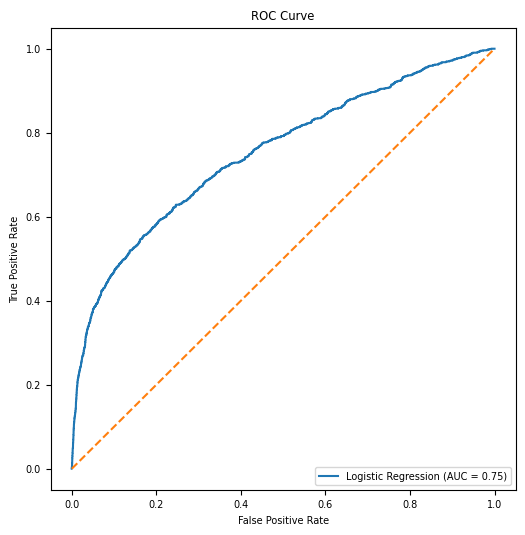

In [ ]:
# ROC CURVE + AUC (use predicted PROBABILITIES)
y_prob = logreg.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
# plot the ROC curve, labelled with the AUC, plus the diagonal
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label='Logistic Regression (AUC = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], linestyle = "--")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

### <span style="color:#990000">Q10. About 12% of clients subscribe, so predicting “no” for everyone already scores ~88%. What did your lazy baseline get, how close is the model’s accuracy, and what does <b>AUC</b> capture that accuracy misses?</span>

My lazy baseline got to the 88% and the AUC captures the exact number and difference between predicted and actual values that accuracy misses.

## 9) Campaign simulation: who should the bank call?

Turn the model into a decision. Rank the **test** clients by predicted probability, “call” the **top 20%**, and compare subscribers reached vs calling 20% **at random**.

In [ ]:
budget = 0.20   # the call centre can phone the top 20%

# 1. table of each test client's true label and predicted probability
y_prob = logreg.predict_proba(X_test_scaled)[:, 1]

results = pd.DataFrame({"Actual": y_test, "Predicted": y_prob})

# 2. sort by probability (highest first) and take the top 20%
results = results.sort_values(by="Predicted", ascending = False)

top_num = int(len(results) * budget)
top_clients = results.head(top_num)

# 3. how many ACTUAL subscribers are in that top 20%?
model_subscribers = (top_clients["Actual"] == 1).sum()

# 4. how many subscribers would 20% AT RANDOM reach?
total_subscribers = (results["Actual"] == 1).sum()
random_reach_subscribers = total_subscribers * budget

# 5. print both and the lift (model / random)
lift = model_subscribers / random_reach_subscribers

print("Clients called: ", top_num)

print("Model subscribers:", model_subscribers)
print("Random subscribers:", random_reach_subscribers)
print("Lift:", round(lift, 2))

Clients called:  1808
Model subscribers: 564
Random subscribers: 211.60000000000002
Lift: 2.67


## 10) Recommendation to the bank (storytelling)

### <span style="color:#990000">Q11. In 3–5 sentences for a bank manager (no jargon): whom should the bank call first, and roughly how much better is your model than calling at random? Name one honest limitation.</span>

> To maximize campaign success, the bank should prioritize calling clients who have previously subscribed during previous campaigns. Our model is able to identify these clients and has a 2.67 times lift, meaning it is 2.67 times better than calling at random. However, one limitation is that the model relies on past campaign history, so it will be less effective on new clients who have participated in no prior campaigns.

<div style="border-left:6px solid #4E3629;background:#F2EEE9;padding:14px 18px;border-radius:4px;font-family:Lato,Arial,sans-serif;"><b style="color:#4E3629;">Section 11 — Stretch goal (optional, leaderboard / bonus)</b> — the core deliverable is your logistic pipeline. If you finish early, train a Random Forest and compare its AUC. Skipping it costs nothing.</div>

Random forest accuracy: 0.8931


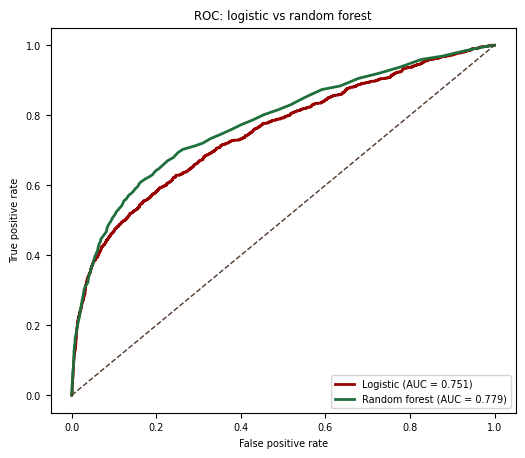

In [ ]:
# OPTIONAL — Random Forest
#rf = RandomForestClassifier(n_estimators=200, random_state=42)
# <Your code here>      # rf.fit(...)
# accuracy, then probabilities -> ROC + AUC, plotted against logistic
# <Your code here>

### <span style="color:#990000">Q12. (Optional) How did the Random Forest’s AUC compare? Which model would you ship to the bank, and why?</span>

> *Write your team's answer in this cell (double-click to edit). No word limit.*

## 12) Team retrospective

### <span style="color:#990000">Q13. What broke in your collaboration — a merge conflict, a missed meeting across time zones, a version mismatch, uneven workload — and how did you fix it? What will you do differently next time?</span>

> *Write your team's answer in this cell (double-click to edit). No word limit.*
"One thing that broke in our collaboration was trying to figure out meeting times and how to work on the notebook at the same time to avoid merge errors. We combatted these issues by creating separate documents with our respective code and then having one person combine them on this document during our call. Next time, we would try to have a couple more meetings with our team because everyone was busy for 4th of July and the days leading up to it."

## Deliverables & submission

- Submit the completed **`.ipynb`**, named with your team number, via **GitHub** (e.g. **`Team7_logistic_regression_1_3.ipynb`**).
- Include a **`ReadMe.txt`** with members’ names, your **team charter** (times *with time zones*, section owners), and a **contribution log** (each member: what they did + their commits).
- **Before submitting:** **Runtime → Restart and run all** so the notebook runs top-to-bottom with no errors.
- Give repo access to **`gk2311`** on GitHub and paste the link in the Canvas submission.

<div style="font-size:12px;color:#8A7F75;font-family:Lato,Arial,sans-serif;">Dataset: S. Moro, R. Laureano and P. Cortez (2011). <i>Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology.</i> In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference — ESM’2011, pp. 117–121, Guimarães, Portugal, October 2011. EUROSIS. Available: http://hdl.handle.net/1822/14838</div>